In [1]:
from pathlib import Path
import importlib.util
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dann-rop-v3').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPT_PATH = PROJECT_ROOT / 'dann-rop-v3' / 'phase1_origa_df_cut.py'
assert SCRIPT_PATH.exists(), f'Arquivo não encontrado: {SCRIPT_PATH}'

spec = importlib.util.spec_from_file_location('phase1_cut', SCRIPT_PATH)
phase1_cut = importlib.util.module_from_spec(spec)
spec.loader.exec_module(phase1_cut)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('PROJECT_ROOT =', PROJECT_ROOT)
print('SCRIPT_PATH =', SCRIPT_PATH)
print('device =', device)

Número de arquivos de imagem encontrados: 650
Número de arquivos válidos após filtragem: 0
[Fallback ORIGA] usando origa_processed.csv | amostras=650
Número de arquivos de imagem encontrados: 6004
Número de arquivos válidos após filtragem: 6004
Tamanho Dataset Source (ORIGA): 650
Tamanho Dataset Target (ROP): 6004
PROJECT_ROOT = /home/lucas/mestrado/ROP/ROP_CLASSIFICATION
SCRIPT_PATH = /home/lucas/mestrado/ROP/ROP_CLASSIFICATION/dann-rop-v3/phase1_origa_df_cut.py
device = cuda:0


In [2]:
# Mesmos datasets do script (já montados no import)
source_dataset = phase1_cut.source_dataset
target_dataset = phase1_cut.target_dataset

print('Source size:', len(source_dataset))
print('Target size:', len(target_dataset))

Source size: 650
Target size: 6004


In [3]:
def sample_indices(n, max_n=800, seed=42):
    rng = np.random.default_rng(seed)
    k = min(max_n, n)
    return rng.choice(n, size=k, replace=False)

def extract_features_from_subset(model, dataset, indices, batch_size=64):
    subset = torch.utils.data.Subset(dataset, indices.tolist())
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=4)

    feats, labels = [], []
    model.eval()
    with torch.no_grad():
        for imgs, y, _ in loader:
            imgs = imgs.to(device)
            f = model.backbone.features(imgs)
            f = model.backbone.avgpool(f)
            f = torch.flatten(f, 1)
            feats.append(f.cpu().numpy())
            labels.extend(y.numpy().tolist())

    return np.concatenate(feats, axis=0), np.array(labels)

def run_tsne(x, seed=42):
    tsne = TSNE(n_components=2, init='pca', perplexity=30, learning_rate='auto', random_state=seed)
    return tsne.fit_transform(x)

def plot_tsne(emb, domains, labels, title):
    label_name = np.where(labels == 1, 'Doença', 'Normal')

    color_map = {'ORIGA': '#1f77b4', 'ROP': '#ff7f0e'}
    marker_map = {'Normal': 'o', 'Doença': 'x'}

    fig, ax = plt.subplots(figsize=(10, 8))
    for dom in ['ORIGA', 'ROP']:
        for ln in ['Normal', 'Doença']:
            mask = (domains == dom) & (label_name == ln)
            if mask.sum() == 0:
                continue
            ax.scatter(
                emb[mask, 0],
                emb[mask, 1],
                c=color_map[dom],
                marker=marker_map[ln],
                alpha=0.65,
                s=18,
                label=f'{dom} - {ln}',
            )

    ax.set_title(title)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.grid(True, alpha=0.2)
    ax.legend(loc='best', fontsize=9, frameon=True)
    plt.tight_layout()
    plt.show()

In [4]:
# amostragem fixa para comparação antes/depois
idx_src = sample_indices(len(source_dataset), max_n=800, seed=42)
idx_tgt = sample_indices(len(target_dataset), max_n=800, seed=42)

print('Amostras ORIGA:', len(idx_src))
print('Amostras ROP:', len(idx_tgt))

Amostras ORIGA: 650
Amostras ROP: 800


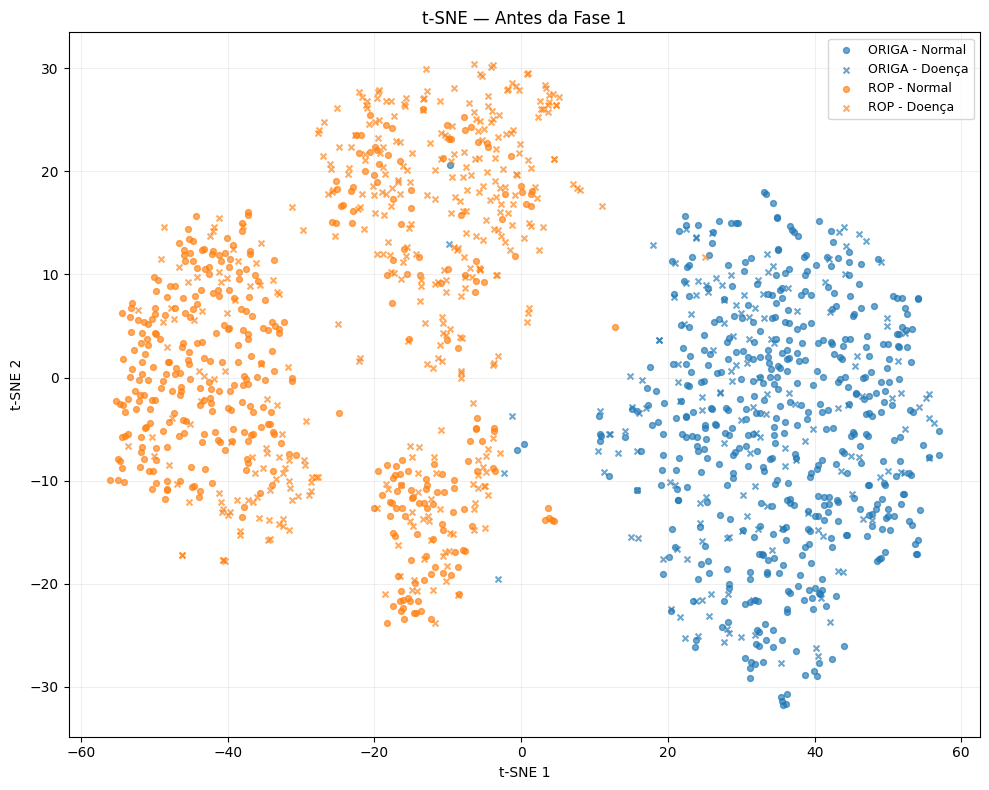

In [5]:
# ANTES: EfficientNet-B0 pré-treinado (sem pesos do seu treino DANN)
model_before = phase1_cut.EfficientNetDANN(num_classes=2, pre_trained=True).to(device)

feat_src_before, lab_src_before = extract_features_from_subset(model_before, source_dataset, idx_src)
feat_tgt_before, lab_tgt_before = extract_features_from_subset(model_before, target_dataset, idx_tgt)

X_before = np.vstack([feat_src_before, feat_tgt_before])
dom_before = np.array(['ORIGA'] * len(feat_src_before) + ['ROP'] * len(feat_tgt_before))
lab_before = np.concatenate([lab_src_before, lab_tgt_before])

emb_before = run_tsne(X_before, seed=42)
plot_tsne(emb_before, dom_before, lab_before, 't-SNE — Antes da Fase 1')

In [6]:
# DEPOIS: carrega um checkpoint salvo no padrão dann_model_fold_*.pth
ckpt_dir = PROJECT_ROOT / 'dann-rop-v3' / 'checkpoints' / 'phase1_cut'
ckpt_paths = sorted(ckpt_dir.glob('dann_model_fold_*.pth'))

print('Checkpoint dir:', ckpt_dir)
print('Encontrados:', len(ckpt_paths))
for p in ckpt_paths:
    print('-', p.name)

assert len(ckpt_paths) > 0, 'Nenhum checkpoint encontrado. Aguarde o treino terminar.'

# escolha do fold para visualização (mude aqui se quiser)
FOLD_TO_USE = 1
selected_ckpt = ckpt_dir / f'dann_model_fold_{FOLD_TO_USE}.pth'
assert selected_ckpt.exists(), f'Checkpoint não encontrado: {selected_ckpt}'

print('Usando checkpoint:', selected_ckpt.name)

Checkpoint dir: /home/lucas/mestrado/ROP/ROP_CLASSIFICATION/dann-rop-v3/checkpoints/phase1_cut
Encontrados: 3
- dann_model_fold_1.pth
- dann_model_fold_2.pth
- dann_model_fold_3.pth
Usando checkpoint: dann_model_fold_1.pth


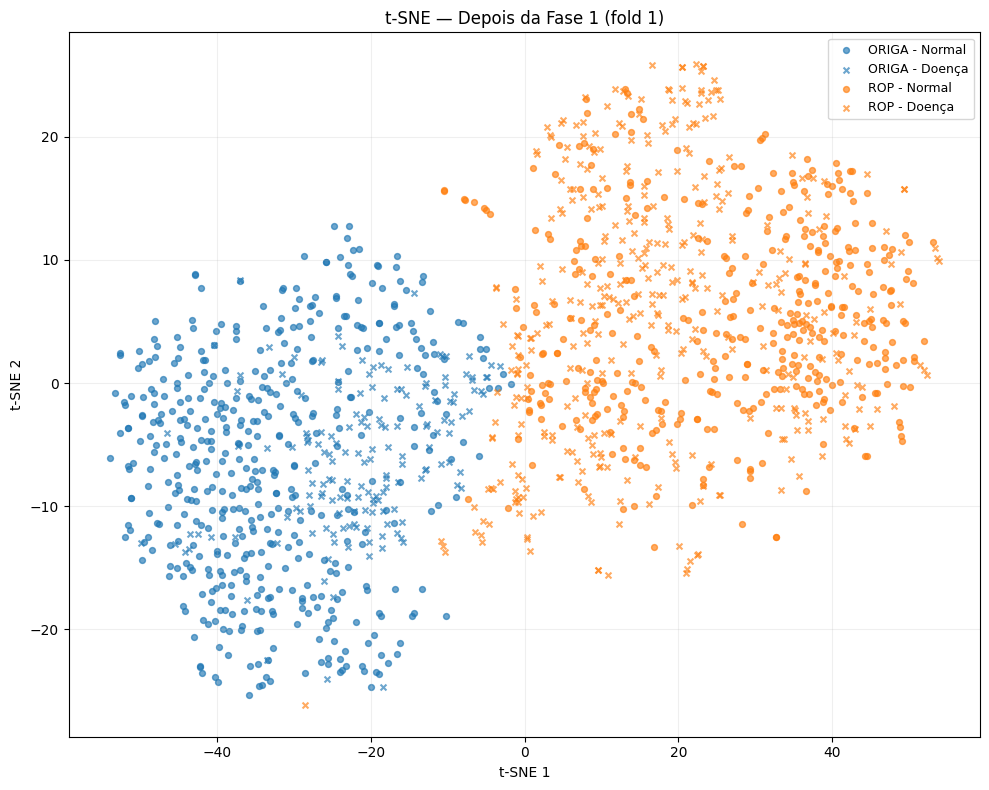

In [7]:
model_after = phase1_cut.EfficientNetDANN(num_classes=2, pre_trained=False).to(device)
state = torch.load(selected_ckpt, map_location=device)
model_after.load_state_dict(state, strict=True)

feat_src_after, lab_src_after = extract_features_from_subset(model_after, source_dataset, idx_src)
feat_tgt_after, lab_tgt_after = extract_features_from_subset(model_after, target_dataset, idx_tgt)

X_after = np.vstack([feat_src_after, feat_tgt_after])
dom_after = np.array(['ORIGA'] * len(feat_src_after) + ['ROP'] * len(feat_tgt_after))
lab_after = np.concatenate([lab_src_after, lab_tgt_after])

emb_after = run_tsne(X_after, seed=42)
plot_tsne(emb_after, dom_after, lab_after, f't-SNE — Depois da Fase 1 (fold {FOLD_TO_USE})')

In [ ]:
# salvar os pontos para comparação externa
out_dir = PROJECT_ROOT / 'dann-rop-v3' / 'artifacts' / 'tsne_phase1_cut'
out_dir.mkdir(parents=True, exist_ok=True)

df_before = pd.DataFrame({
    'tsne_1': emb_before[:, 0],
    'tsne_2': emb_before[:, 1],
    'domain': dom_before,
    'label': lab_before,
})

df_after = pd.DataFrame({
    'tsne_1': emb_after[:, 0],
    'tsne_2': emb_after[:, 1],
    'domain': dom_after,
    'label': lab_after,
})

before_path = out_dir / f'tsne_before_phase1_fold{FOLD_TO_USE}.csv'
after_path = out_dir / f'tsne_after_phase1_fold{FOLD_TO_USE}.csv'

df_before.to_csv(before_path, index=False)
df_after.to_csv(after_path, index=False)

print('Salvo:')
print('-', before_path)
print('-', after_path)